In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3554, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [6]:
latlong = pd.read_csv('latlong.csv')

In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [9]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [10]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [11]:
new_df = df.merge(latlong, on='sector')

In [12]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [13]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [14]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [15]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\abhay\AppData\Local\Temp\ipykernel_23428\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [16]:
new_df.to_csv('data_viz1.csv',index=False)

In [17]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [18]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,property_id
0,5 BHK Flat in Sector 62 Gurgaon,flat,pioneer araya,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,...,"1302, Sector 62 Gurgaon, Gurgaon, Haryana",10.0,North-East,1 to 5 Year Old,"['Paras Trinity Shopping Mall', 'Golf Course E...","3, 4 and 5 bhk residential apartments & pentho...","['4 Fan', '15 Light', '6 AC', '1 Modular Kitch...","['Security / Fire Alarm', 'Private Garden / Te...","['Green Area5 out of 5', 'Construction4 out of...",J69118026
1,12 Bedroom House for sale in Sector 40 Gurgaon,house,independent,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,...,"Sector 40 Gurgaon, Gurgaon, Haryana",4.0,NaN,0 to 1 Year Old,"['Huda city centre metro station', 'Icici bank...",Newly constructed 12 bhk independent floorwise...,"['5 Wardrobe', '1 Water Purifier', '1 Exhaust ...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Lifestyle4 out of 5...",G69453034
2,2 BHK Flat in Sector 79 Gurgaon,flat,m3m golf hills,1.45,10211.0,1420.0,Carpet area: 1420 (131.92 sq.m.),2,2,3 Balconies,...,"Sector 79 Gurgaon, Gurgaon, Haryana",15.0,NaN,Jul 2027,"['Petrol Pump Indian Oil', 'Petrol Pump', 'Rao...",Residential apartment for sell.Located on 15th...,[],NaN,"['Environment4 out of 5', 'Lifestyle3 out of 5...",D69857690
3,1 Bedroom House for sale in Sector 39 Gurgaon,house,independent,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,...,"925, Sector 39 Gurgaon, Gurgaon, Haryana",2.0,NaN,10+ Year Old,"['State bank of india ATM', 'Axis bank ATM', '...",Sector 39 gurgaon is one of gurgaon's most sou...,[],"['Feng Shui / Vaastu Compliant', 'Maintenance ...","['Environment4 out of 5', 'Lifestyle4 out of 5...",X67948578
4,4 BHK Flat in Sector 69 Gurgaon,flat,tulip purple,1.92,8000.0,2400.0,Super Built up area 2400(222.97 sq.m.),4,5,3+ Balconies,...,"Sector 69 Gurgaon, Gurgaon, Haryana",5.0,East,1 to 5 Year Old,"['Sector 55-56 metro station', 'Omaxe Gurgaon ...",This 4 bhk apartment is available for sale in ...,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '11 L...","['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Environment4 out of 5', 'Lifestyle4 out of 5...",O69569386


In [19]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [20]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Private Garden / Te...",sector 36
1,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 89
2,NaN,sohna road
3,"['Feng Shui / Vaastu Compliant', 'Maintenance ...",sector 92
4,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 102


In [21]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [22]:
main

['Security / Fire Alarm',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Water purifier',
 'False Ceiling Lighting',
 'Water Storage',
 'Piped-gas',
 'Visitor Parking',
 'Internet/wi-fi connectivity',
 'Spacious Interiors',
 'Feng Shui / Vaastu Compliant',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',


In [23]:
from wordcloud import WordCloud

In [24]:
feature_text = ' '.join(main)

In [25]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [26]:
feature_text

'Security / Fire Alarm Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Piped-gas Internet/wi-fi connectivity Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Shopping Centre Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Security / Fire Alarm Water purifier False Ceiling Lighting Water Storage Piped-gas Visitor Parking Internet/wi-fi connectivity Spacious Interiors Feng Shui / Vaastu Compliant Maintenance Staff Water Storage Park Visitor Parking Waste Disposal Rain Water Harvesting Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage 

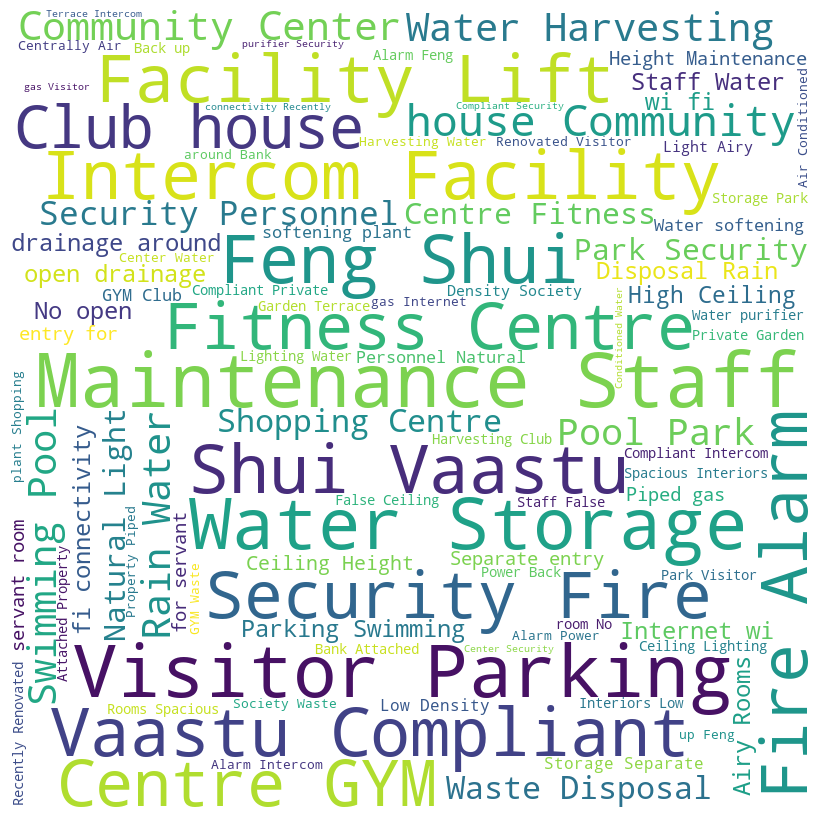

In [27]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [28]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [29]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [30]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [31]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\abhay\AppData\Local\Temp\ipykernel_23428\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\abhay\AppData\Local\Temp\ipykernel_23428\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

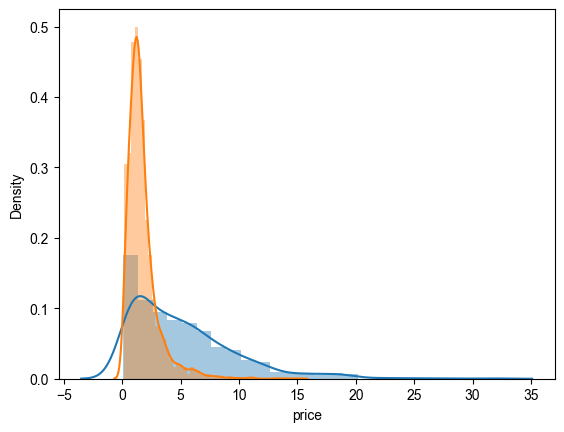

In [32]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [33]:
new_df['sector'].unique().tolist().insert(0,'overall')